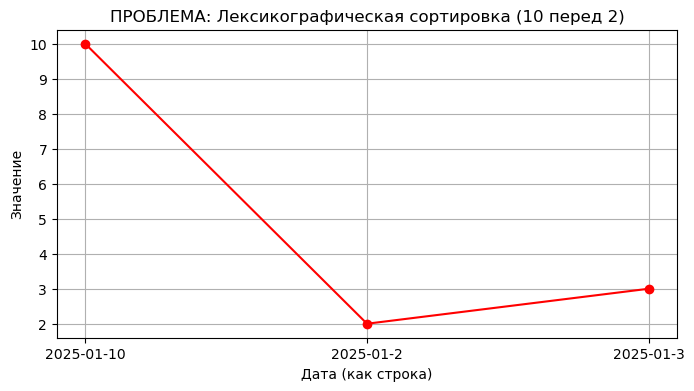

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_bug = pd.DataFrame({
    "date": ["2025-01-10", "2025-01-2", "2025-01-3"],
    "value": [10, 2, 3]
})

df_bug = df_bug.sort_values("date")

plt.figure(figsize=(8, 4))
plt.plot(df_bug["date"], df_bug["value"], marker='o', color='red')
plt.title("ПРОБЛЕМА: Лексикографическая сортировка (10 перед 2)")
plt.xlabel("Дата (как строка)")
plt.ylabel("Значение")
plt.grid(True)
plt.show()

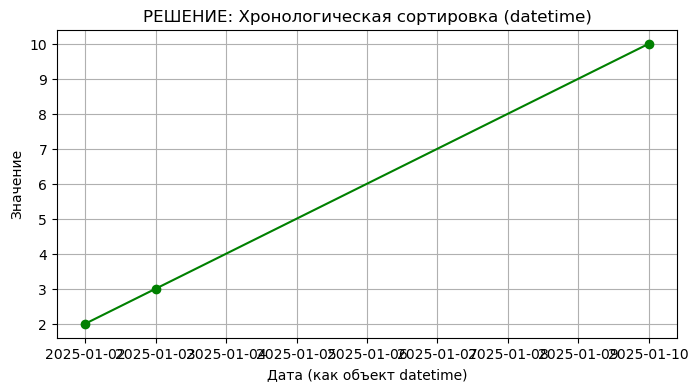

In [3]:
df_fixed = df_bug.copy()
df_fixed['date'] = pd.to_datetime(df_fixed['date'])

df_fixed = df_fixed.sort_values("date")

plt.figure(figsize=(8, 4))
plt.plot(df_fixed["date"], df_fixed["value"], marker='o', color='green')
plt.title("РЕШЕНИЕ: Хронологическая сортировка (datetime)")
plt.xlabel("Дата (как объект datetime)")
plt.ylabel("Значение")
plt.grid(True)
plt.show()

In [5]:
import pandas as pd
import os
import glob

folder_path = '../data/normalized/variant_20/'

files = glob.glob(os.path.join(folder_path, "*.csv"))

if not files:
    print(f"Файлы не найдены в {folder_path}. Проверь путь!")
else:
    latest_file = max(files, key=os.path.getctime)
    print(f"✅ Загружаю файл: {latest_file}")
    
    df = pd.read_csv(latest_file)
    
    if 'holiday_date' in df.columns:
        df = df.rename(columns={'holiday_date': 'date'})
    
    df['date'] = pd.to_datetime(df['date'])
    display(df.head())

✅ Загружаю файл: ../data/normalized/variant_20\2026-03-19_11-39-15_holidays_germany.csv


,date,local_name,eng_name,category
0,2025-01-01,Neujahr,New Year's Day,Public
1,2025-01-06,Heilige Drei Könige,Epiphany,Public
2,2025-03-08,Internationaler Frauentag,International Women's Day,Public
3,2025-04-18,Karfreitag,Good Friday,Public
4,2025-04-20,Ostersonntag,Easter Sunday,Public


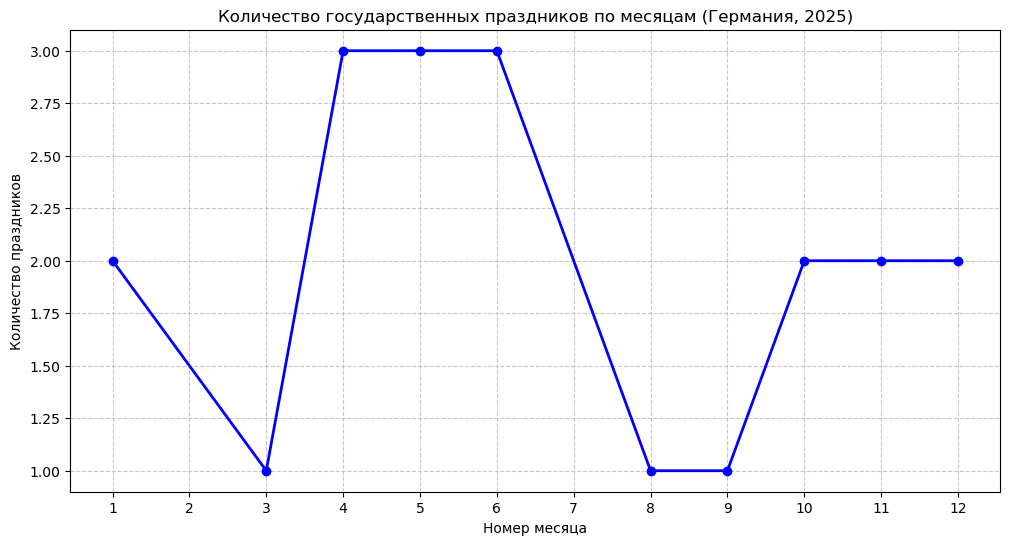

In [6]:
df['month_num'] = df['date'].dt.month
monthly_data = df.groupby('month_num').size()

plt.figure(figsize=(12, 6))
plt.plot(monthly_data.index, monthly_data.values, marker='o', linestyle='-', color='b', linewidth=2)

plt.title("Количество государственных праздников по месяцам (Германия, 2025)")
plt.xlabel("Номер месяца")
plt.ylabel("Количество праздников")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('../docs/figures/week7_timeseries.png')
plt.show()

График демонстрирует неравномерное распределение выходных. Пики приходятся на весенний период (апрель-май) и конец года (декабрь), что соответствует религиозным и государственным праздника.

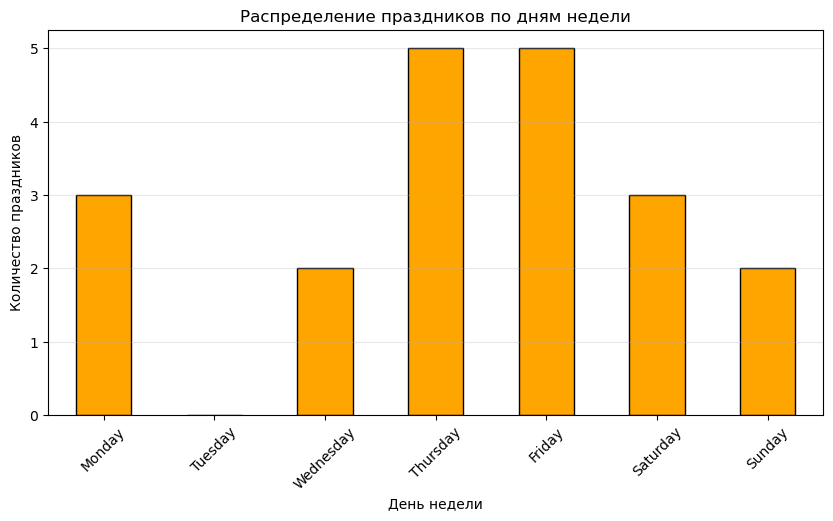

In [ ]:
df['day_name'] = df['date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_name'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='orange', edgecolor='black')

plt.title("Распределение праздников по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество праздников")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.savefig('../docs/figures/week7_ranking.png')
plt.show()

График демострирует количество праздников, распределенных по дням недели.

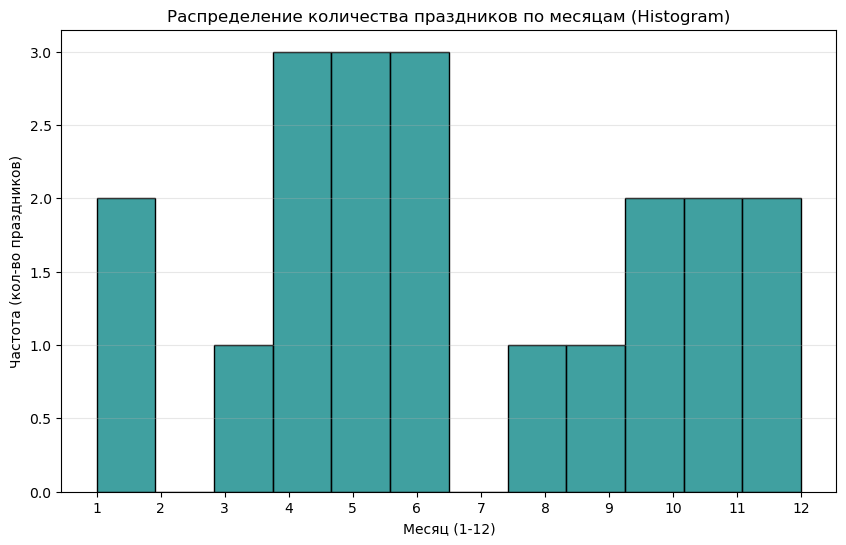

In [15]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['date'].dt.month, bins=12, kde=False, color='teal')

plt.title("Распределение количества праздников по месяцам (Histogram)")
plt.xlabel("Месяц (1-12)")
plt.ylabel("Частота (кол-во праздников)")
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)

plt.savefig('../docs/figures/week7_distribution.png')
plt.show()

Распределение показывает асимметрию: праздники сконцентрированы в первой половине года и в самом конце (декабрь), в то время как август и сентябрь остаются рабочими.